## notebook to generate graphs for nanogpt

### loss curves

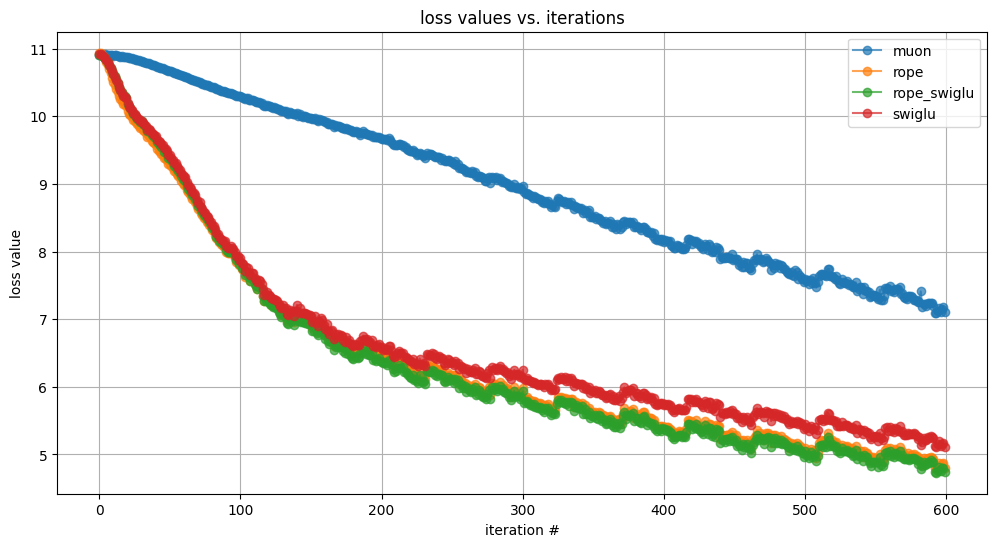

In [8]:
import glob
import re
import numpy as np
import matplotlib.pyplot as plt

# find log files
files = sorted(glob.glob("../results/log_*"))
if not files:
    raise FileNotFoundError("No files matched ../results/log_*")

# plot
plt.figure(figsize=(12, 6))

# parse and plot each file separately
pattern = re.compile(r'^\s*(\d+)\s+train\s+([+-]?\d*\.?\d+(?:[eE][+-]?\d+)?)')
for fp in files:
    xs, ys = [], []
    with open(fp, 'r') as f:
        for line in f:
            m = pattern.match(line)
            if m:
                xs.append(int(m.group(1)))
                ys.append(float(m.group(2)))
    
    x_vals = np.array(xs, dtype=int)
    y_vals = np.array(ys, dtype=float)
    # convert and sort by x
    order = np.argsort(x_vals)
    x_vals = x_vals[order]
    y_vals = y_vals[order]
    
    # extract filename for label
    filename = fp.split('/')[-1].replace('log_', '').replace('.txt', '')
    plt.plot(x_vals[:600], y_vals[:600], marker='o', label=filename, alpha=0.7)

plt.xlabel('iteration #')
plt.ylabel('loss value')
plt.title('loss values vs. iterations')
plt.legend()
plt.grid(True)
plt.show()